In [59]:
import sys
print(sys.executable)

c:\Users\feder\Documents\tesi-ml\venv\Scripts\python.exe


In [60]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebook" else Path.cwd().resolve()
DATA_GOLD = BASE_DIR / "data" / "gold"

print("BASE_DIR:", BASE_DIR)
print("DATA_GOLD:", DATA_GOLD)

BASE_DIR: C:\Users\feder\Documents\tesi-ml
DATA_GOLD: C:\Users\feder\Documents\tesi-ml\data\gold


In [61]:
input_path = DATA_GOLD / "final_dataset_clean.csv"

df = pd.read_csv(input_path)

print("Dataset caricato da:", input_path)
print("Shape:", df.shape)
df.head()

Dataset caricato da: C:\Users\feder\Documents\tesi-ml\data\gold\final_dataset_clean.csv
Shape: (92, 24)


,profile_id,target_role,research_consent_given,created_at,updated_at,job_satisfaction,D1,D2,D3,D4,...,suggested_role,triage_decision_quality,triage_strategy_adaptation,triage_decision_speed,gonogo_inhibition_control,gonogo_attention_stability,gonogo_response_stability,neg_interaction_balance,neg_decision_drive,neg_outcome_quality
0,3eafff1d-e7a2-4e47-9a9d-e99388ee041b,sales_ops,True,2026-03-12T12:51:24.266+00:00,2026-03-12T12:54:54.401519+00:00,5,85.0,80.0,63.0,75.0,...,receptionist,0.750,0.416667,0.000168,0.866667,0.155556,0.013497,0.116667,0.800000,0.716667
1,1ac56240-ef90-4360-a0d1-585b60886757,sales_ops,True,2026-03-14T12:02:38.609+00:00,2026-03-14T12:04:33.557255+00:00,3,55.0,60.0,56.0,56.0,...,sales_ops,0.625,0.550000,0.000219,0.733333,0.133333,0.010196,0.116667,0.800000,0.716667
2,867d1f34-4148-42e9-865b-15889571ad89,sales_ops,True,2026-03-12T13:23:08.27+00:00,2026-03-12T13:28:30.088589+00:00,4,75.0,75.0,81.0,44.0,...,receptionist,0.500,0.416667,0.000098,0.800000,0.177778,0.123456,0.233333,0.716667,0.625000
3,d87cecce-e8cd-4a21-afeb-e6f544cfa6bf,sales_ops,True,2026-03-13T12:23:22.602+00:00,2026-03-13T12:26:21.902876+00:00,4,65.0,75.0,94.0,25.0,...,receptionist,0.375,0.583333,0.000214,0.800000,0.111111,0.023210,0.416667,0.550000,0.550000
4,dc5e1d44-459a-43dd-940e-00786d4f84ca,sales_ops,True,2026-03-17T14:08:22.974+00:00,2026-03-17T17:44:22.360837+00:00,5,60.0,95.0,25.0,50.0,...,receptionist,0.250,0.750000,0.000169,0.466667,0.244444,0.010166,0.200000,0.616667,0.633333


In [62]:
print("Colonne:")
print(df.columns.tolist())

print("\nDuplicati profile_id:", df["profile_id"].duplicated().sum())

print("\nMissing per colonna:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDistribuzione target_role:")
print(df["target_role"].value_counts())

print("\nDistribuzione job_satisfaction:")
print(df["job_satisfaction"].value_counts().sort_index())

Colonne:
['profile_id', 'target_role', 'research_consent_given', 'created_at', 'updated_at', 'job_satisfaction', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6_result', 'D6_learning', 'D6_relation', 'suggested_role', 'triage_decision_quality', 'triage_strategy_adaptation', 'triage_decision_speed', 'gonogo_inhibition_control', 'gonogo_attention_stability', 'gonogo_response_stability', 'neg_interaction_balance', 'neg_decision_drive', 'neg_outcome_quality']

Duplicati profile_id: 0

Missing per colonna:
profile_id                    0
target_role                   0
research_consent_given        0
created_at                    0
updated_at                    0
job_satisfaction              0
D1                            0
D2                            0
D3                            0
D4                            0
D5                            0
D6_result                     0
D6_learning                   0
D6_relation                   0
suggested_role                0
triage_decision_quality    

In [63]:
orientation_cols = [
    "D1", "D2", "D3", "D4", "D5",
    "D6_result", "D6_learning", "D6_relation"
]

game_cols = [
    "triage_decision_quality", "triage_strategy_adaptation", "triage_decision_speed",
    "gonogo_inhibition_control", "gonogo_attention_stability", "gonogo_response_stability",
    "neg_interaction_balance","neg_decision_drive", "neg_outcome_quality"
]

In [64]:
df[orientation_cols + game_cols + ["job_satisfaction"]].describe().T

,count,mean,std,min,25%,50%,75%,max
D1,92.0,61.250000,18.525673,10.000000,50.000000,60.000000,75.000000,100.000000
D2,92.0,61.358696,15.638486,20.000000,55.000000,60.000000,75.000000,95.000000
D3,92.0,54.782609,20.705590,13.000000,44.000000,50.000000,69.000000,100.000000
D4,92.0,54.902174,14.948306,19.000000,50.000000,50.000000,63.000000,94.000000
D5,92.0,51.206522,15.434041,19.000000,44.000000,50.000000,63.000000,88.000000
D6_result,92.0,75.456522,20.001875,25.000000,67.000000,79.000000,92.000000,100.000000
D6_learning,92.0,79.652174,19.546189,8.000000,67.000000,83.000000,100.000000,100.000000
D6_relation,92.0,76.978261,20.385827,8.000000,67.000000,83.000000,92.000000,100.000000
triage_decision_quality,92.0,0.525815,0.206802,0.125000,0.375000,0.500000,0.750000,0.875000
triage_strategy_adaptation,92.0,0.670497,0.210931,0.100000,0.547917,0.708333,0.833333,1.000000


In [65]:
df.groupby("target_role")[orientation_cols + game_cols + ["job_satisfaction"]].mean()

,D1,D2,D3,D4,D5,D6_result,D6_learning,D6_relation,triage_decision_quality,triage_strategy_adaptation,triage_decision_speed,gonogo_inhibition_control,gonogo_attention_stability,gonogo_response_stability,neg_interaction_balance,neg_decision_drive,neg_outcome_quality,job_satisfaction
target_role,,,,,,,,,,,,,,,,,,
developer,68.437500,55.625000,55.187500,56.593750,52.656250,75.500000,85.187500,71.875000,0.546875,0.661979,0.000294,0.698958,0.320486,0.031031,0.251562,0.641146,0.630469,3.343750
receptionist,58.181818,66.969697,53.121212,55.151515,47.666667,77.000000,77.787879,83.818182,0.553030,0.655808,0.000415,0.613805,0.401235,0.061701,0.200000,0.652525,0.662374,3.424242
sales_ops,56.481481,61.296296,56.333333,52.592593,53.814815,73.518519,75.370370,74.666667,0.467593,0.698545,0.000463,0.686420,0.339918,0.028646,0.284568,0.563580,0.600309,3.814815


In [66]:
corr = df[orientation_cols + game_cols + ["job_satisfaction"]].corr()
corr

,D1,D2,D3,D4,D5,D6_result,D6_learning,D6_relation,triage_decision_quality,triage_strategy_adaptation,triage_decision_speed,gonogo_inhibition_control,gonogo_attention_stability,gonogo_response_stability,neg_interaction_balance,neg_decision_drive,neg_outcome_quality,job_satisfaction
D1,1.000000,-0.121615,0.117601,0.047866,0.137062,0.252744,0.274493,-0.162728,-0.144761,-0.101506,-0.104968,0.076389,0.020208,0.101931,-0.201091,0.350998,0.172348,0.009061
D2,-0.121615,1.000000,0.178075,-0.145150,0.045036,0.130440,0.172686,0.456126,0.016643,-0.170781,-0.222028,0.030883,-0.150161,0.106918,-0.273349,0.186316,0.289938,-0.098325
D3,0.117601,0.178075,1.000000,-0.283535,0.337683,-0.052401,0.124658,-0.059369,-0.042303,0.025486,-0.056977,0.051114,0.027696,0.126549,-0.236868,0.195797,0.269915,0.048001
D4,0.047866,-0.145150,-0.283535,1.000000,-0.331993,0.152971,0.166269,0.051993,0.159457,0.034080,-0.128978,0.118028,-0.129578,-0.009324,-0.151999,0.169469,0.108678,0.110286
D5,0.137062,0.045036,0.337683,-0.331993,1.000000,-0.031883,0.118335,-0.015667,-0.161353,0.014494,-0.136229,-0.031175,0.005257,0.137733,0.027069,-0.015212,-0.000719,0.171531
D6_result,0.252744,0.130440,-0.052401,0.152971,-0.031883,1.000000,0.698241,0.284267,-0.052028,-0.176300,-0.065188,0.001240,-0.052428,0.042824,-0.244279,0.276832,0.173652,-0.144837
D6_learning,0.274493,0.172686,0.124658,0.166269,0.118335,0.698241,1.000000,0.389939,0.027393,-0.245454,-0.228124,0.138157,-0.158719,0.103011,-0.282493,0.380989,0.238304,-0.123478
D6_relation,-0.162728,0.456126,-0.059369,0.051993,-0.015667,0.284267,0.389939,1.000000,0.031088,-0.104765,-0.131252,0.025120,-0.093171,0.156988,-0.360863,0.229808,0.332926,-0.075995
triage_decision_quality,-0.144761,0.016643,-0.042303,0.159457,-0.161353,-0.052028,0.027393,0.031088,1.000000,0.195345,-0.372300,0.194475,-0.173574,0.102228,-0.087607,0.086394,0.133594,-0.216695
triage_strategy_adaptation,-0.101506,-0.170781,0.025486,0.034080,0.014494,-0.176300,-0.245454,-0.104765,0.195345,1.000000,-0.052365,0.020707,0.066827,-0.184379,0.125853,-0.091218,-0.056500,-0.201728


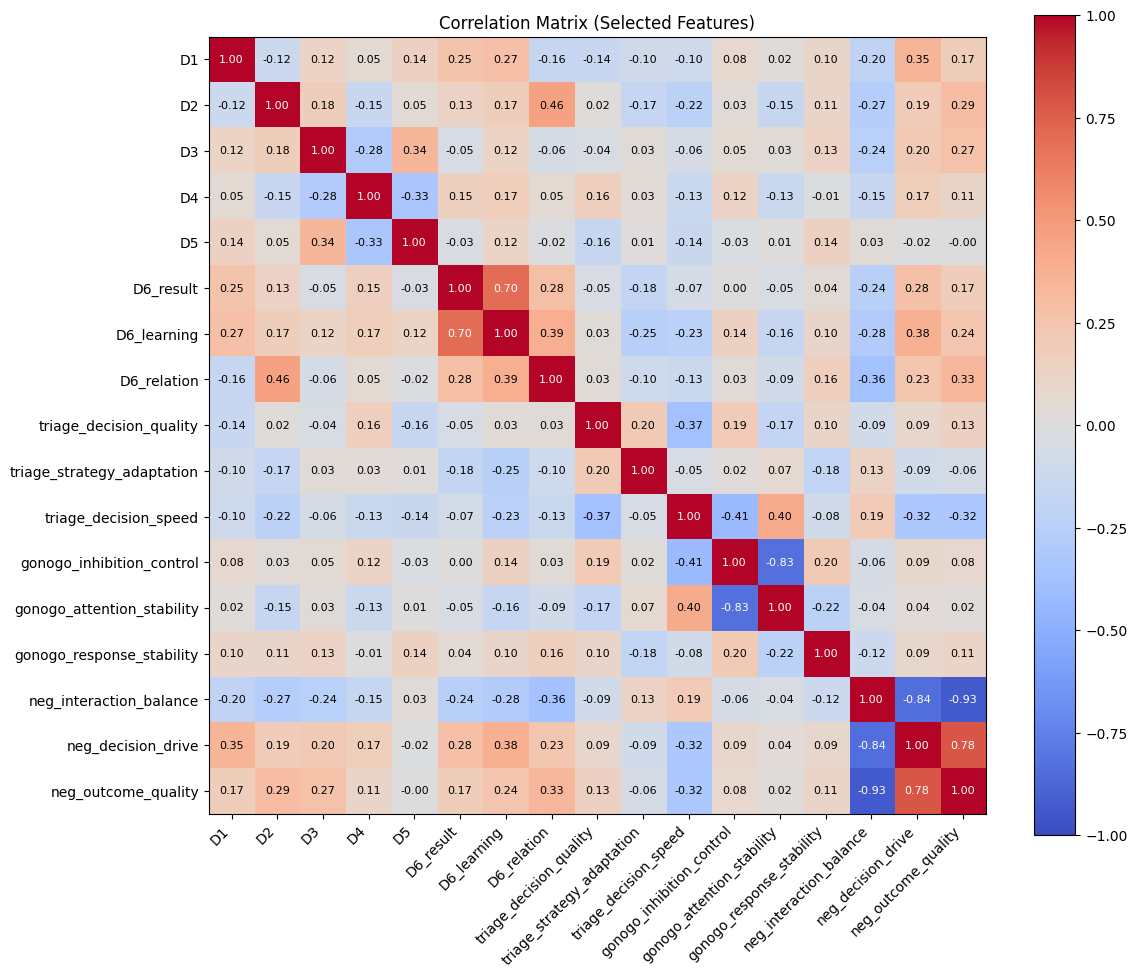

In [153]:
import matplotlib.pyplot as plt
import numpy as np

# colonne da escludere
cols_to_exclude = [
    "distance_to_center",
    "PC1",
    "PC2",
    "cluster",
    "job_satisfaction"
]

# seleziona solo numeriche e rimuovi quelle non utili
df_num = df.select_dtypes(include="number").drop(columns=cols_to_exclude, errors="ignore")

# matrice di correlazione
corr = df_num.corr()

plt.figure(figsize=(12, 10))

im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# etichette
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(np.arange(len(corr.columns)), corr.columns)

# valori dentro le celle
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        plt.text(j, i, f"{val:.2f}",
                 ha="center", va="center",
                 color=color, fontsize=8)

# colorbar
plt.colorbar(im)

plt.title("Correlation Matrix (Selected Features)")
plt.tight_layout()
plt.show()

In [260]:
from sklearn.preprocessing import StandardScaler

orientation_cols = [
    "D1", "D2", "D3", "D4", "D5",
    "D6_result", "D6_learning", "D6_relation"
]

game_cols = ["triage_decision_quality", "triage_strategy_adaptation", "triage_decision_speed",
    "gonogo_inhibition_control", "gonogo_attention_stability", "gonogo_response_stability",
    "neg_interaction_balance","neg_decision_drive", "neg_outcome_quality"]

features = orientation_cols + game_cols

X = df[features].copy()

print("Shape X:", X.shape)

Shape X: (92, 17)


In [68]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [69]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster assegnati:")
print(df["cluster"].value_counts())

Cluster assegnati:
cluster
1    53
2    23
0    16
Name: count, dtype: int64


In [70]:
cluster_profile = df.groupby("cluster").mean(numeric_only=True)

cluster_profile.T

cluster,0,1,2
research_consent_given,1.000000,1.000000,1.000000
job_satisfaction,3.250000,3.471698,3.782609
D1,69.062500,61.603774,55.000000
D2,61.562500,64.056604,55.000000
D3,54.000000,57.415094,49.260870
D4,54.062500,57.735849,48.956522
D5,52.062500,52.226415,48.260870
D6_result,83.312500,79.245283,61.260870
D6_learning,85.000000,86.207547,60.826087
D6_relation,82.250000,81.886792,62.000000


In [71]:
import pandas as pd

crosstab = pd.crosstab(df["cluster"], df["target_role"])

print("Cluster vs ruolo:")
display(crosstab)

Cluster vs ruolo:


target_role,developer,receptionist,sales_ops
cluster,,,
0,5,9,2
1,21,18,14
2,6,6,11


In [72]:
distances = kmeans.transform(X_scaled)
df["distance_to_center"] = distances.min(axis=1)

df[["profile_id", "cluster", "distance_to_center"]].head()

,profile_id,cluster,distance_to_center
0,3eafff1d-e7a2-4e47-9a9d-e99388ee041b,1,3.379913
1,1ac56240-ef90-4360-a0d1-585b60886757,1,2.551913
2,867d1f34-4148-42e9-865b-15889571ad89,1,3.245413
3,d87cecce-e8cd-4a21-afeb-e6f544cfa6bf,1,4.351013
4,dc5e1d44-459a-43dd-940e-00786d4f84ca,1,3.463532


In [73]:
print("Soddisfazione media per cluster:")
display(df.groupby("cluster")["job_satisfaction"].mean())

Soddisfazione media per cluster:


cluster
0    3.250000
1    3.471698
2    3.782609
Name: job_satisfaction, dtype: float64

In [74]:
print("Correlazione distanza vs satisfaction:")
display(df[["distance_to_center", "job_satisfaction"]].corr())

Correlazione distanza vs satisfaction:


,distance_to_center,job_satisfaction
distance_to_center,1.000000,0.215251
job_satisfaction,0.215251,1.000000


In [75]:
df["is_central"] = df["distance_to_center"] < df["distance_to_center"].median()

print("Satisfaction centrali vs periferici:")
display(df.groupby("is_central")["job_satisfaction"].mean())

Satisfaction centrali vs periferici:


is_central
False    3.782609
True     3.239130
Name: job_satisfaction, dtype: float64

In [76]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print("Varianza spiegata:", pca.explained_variance_ratio_)

Varianza spiegata: [0.22654182 0.13129044]


In [219]:
mapping = {}

for c in df["cluster"].unique():
    most_common = df[df["cluster"] == c]["target_role"].value_counts().idxmax()
    mapping[c] = most_common

df["cluster_mapped"] = df["cluster"].map(mapping)

In [220]:
df["correct"] = df["cluster_mapped"] == df["target_role"]

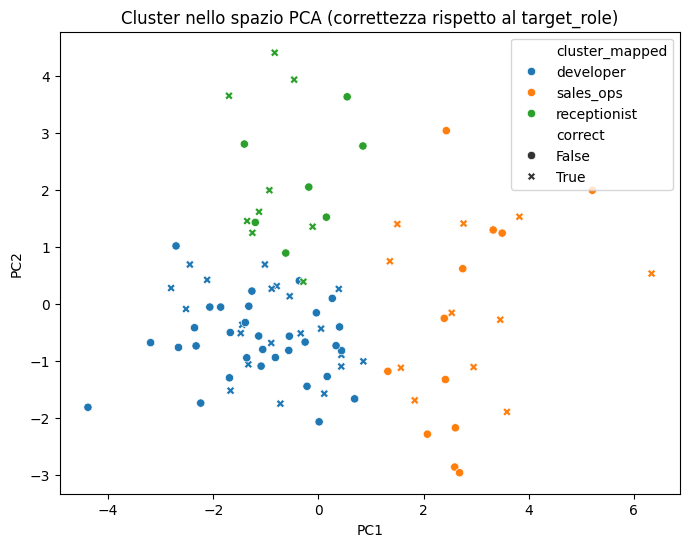

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster_mapped",   # ruolo assegnato
    style="correct"         # True/False
)

plt.title("Cluster nello spazio PCA (correttezza rispetto al target_role)")
plt.show()

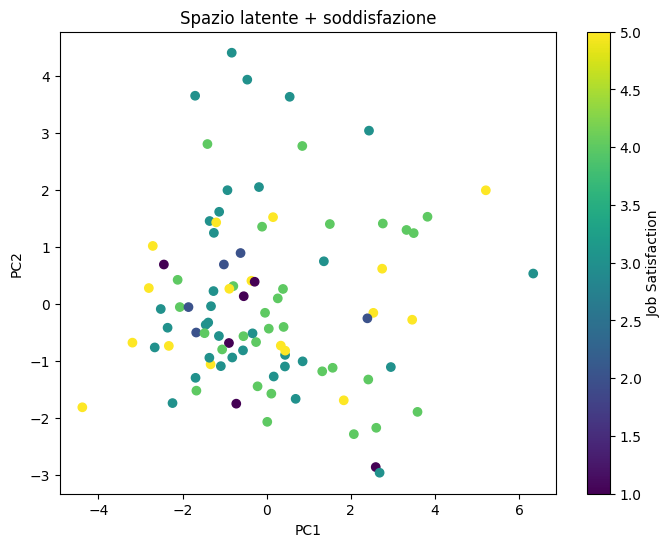

In [78]:
plt.figure(figsize=(8,6))

sc = plt.scatter(
    df["PC1"],
    df["PC2"],
    c=df["job_satisfaction"],
    cmap="viridis"
)

plt.colorbar(sc, label="Job Satisfaction")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spazio latente + soddisfazione")
plt.show()

In [120]:
df["match"] = df["target_role"] == df["suggested_role"]

In [222]:
df["match"] = df["target_role"] == df["suggested_role"]

print("Distribuzione match:")
print(df["match"].value_counts(dropna=False))

print("\nAccuratezza match:")
print(df["match"].mean())

print("\nCrosstab target vs suggested:")
display(pd.crosstab(df["target_role"], df["suggested_role"]))

Distribuzione match:
match
False    51
True     41
Name: count, dtype: int64

Accuratezza match:
0.44565217391304346

Crosstab target vs suggested:


suggested_role,developer,receptionist,sales_ops
target_role,,,
developer,17,5,10
receptionist,10,14,9
sales_ops,9,8,10


In [122]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [223]:
y = df["target_role"]

orientation_cols = [
    "D1", "D2", "D3", "D4", "D5",
    "D6_result", "D6_learning", "D6_relation"
]

game_cols = ["triage_decision_quality", "triage_strategy_adaptation", "triage_decision_speed",
    "gonogo_inhibition_control", "gonogo_attention_stability", "gonogo_response_stability",
    "neg_interaction_balance","neg_decision_drive", "neg_outcome_quality"]

X_A = df[orientation_cols]
X_B = df[orientation_cols + game_cols]
X_C = df[game_cols]

In [224]:
X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_A, y, test_size=0.3, random_state=42, stratify=y
)

X_train_B, X_test_B, _, _ = train_test_split(
    X_B, y, test_size=0.3, random_state=42, stratify=y
)
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y, test_size=0.3, random_state=42, stratify=y
)

In [126]:
import pandas as pd

feat_imp = pd.Series(
    rf_B.feature_importances_,
    index=X_B.columns
).sort_values(ascending=False)

feat_imp

gonogo_response_stability     0.098012
D2                            0.083056
gonogo_attention_stability    0.069268
neg_outcome_quality           0.066940
triage_decision_speed         0.066392
D4                            0.061611
D1                            0.059545
neg_decision_drive            0.058378
triage_strategy_adaptation    0.058107
triage_decision_quality       0.053453
D5                            0.051569
D6_learning                   0.051414
gonogo_inhibition_control     0.050693
D3                            0.047649
neg_interaction_balance       0.046333
D6_result                     0.041675
D6_relation                   0.035906
dtype: float64

In [132]:
from sklearn.model_selection import LeaveOneOut

In [133]:
loo = LeaveOneOut()

rf = RandomForestClassifier(random_state=42)

In [136]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [258]:
print(type(rf_A))
print(hasattr(rf_A, "classes_"))
print(type(rf_B))
print(hasattr(rf_B, "classes_"))

print(type(y_train), type(y_test))
print(type(y_pred_A), type(y_pred_B))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
False
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
False
<class 'pandas.Series'> <class 'pandas.Series'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [138]:
rf_A = RandomForestClassifier(random_state=42)
rf_A.fit(X_train_A, y_train)
y_pred_A = rf_A.predict(X_test_A)

print("rf_A fitted:", hasattr(rf_A, "classes_"))
print("classes_:", rf_A.classes_)

rf_A fitted: True
classes_: ['developer' 'receptionist' 'sales_ops']


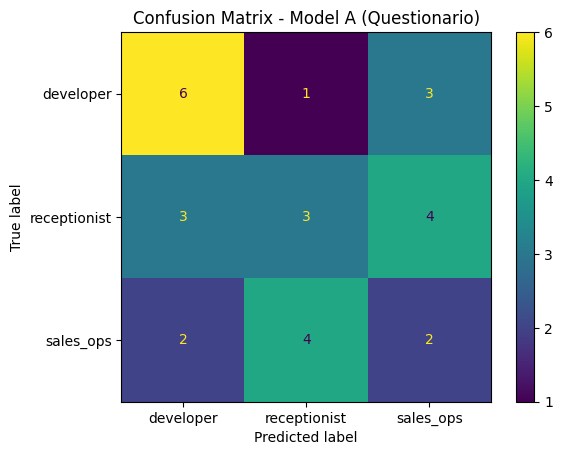

In [139]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_A = RandomForestClassifier(random_state=42)
rf_A.fit(X_train_A, y_train)
y_pred_A = rf_A.predict(X_test_A)

cm_A = confusion_matrix(y_test, y_pred_A, labels=rf_A.classes_)

disp_A = ConfusionMatrixDisplay(
    confusion_matrix=cm_A,
    display_labels=rf_A.classes_
)

disp_A.plot()
plt.title("Confusion Matrix - Model A (Questionario)")
plt.show()

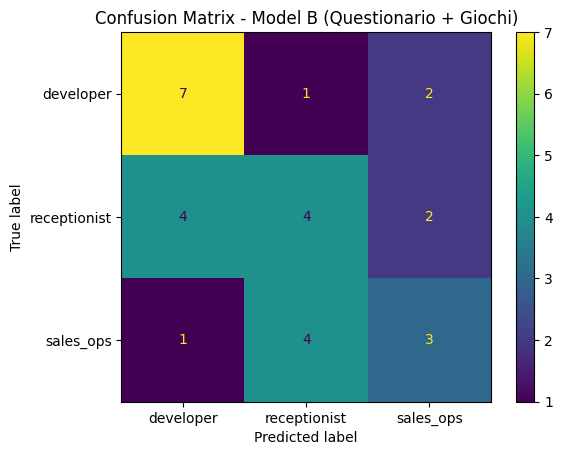

In [140]:
rf_B = RandomForestClassifier(random_state=42)
rf_B.fit(X_train_B, y_train)
y_pred_B = rf_B.predict(X_test_B)

cm_B = confusion_matrix(y_test, y_pred_B, labels=rf_B.classes_)

disp_B = ConfusionMatrixDisplay(
    confusion_matrix=cm_B,
    display_labels=rf_B.classes_
)

disp_B.plot()
plt.title("Confusion Matrix - Model B (Questionario + Giochi)")
plt.show()

In [142]:
from sklearn.linear_model import LogisticRegression

In [143]:
lr_A = LogisticRegression(max_iter=1000)

lr_A.fit(X_train_A, y_train)
y_pred_A_lr = lr_A.predict(X_test_A)

print("=== LOGISTIC A ===")
print(accuracy_score(y_test, y_pred_A_lr))
print(classification_report(y_test, y_pred_A_lr))

=== LOGISTIC A ===
0.4642857142857143
              precision    recall  f1-score   support

   developer       0.53      0.90      0.67        10
receptionist       0.33      0.20      0.25        10
   sales_ops       0.40      0.25      0.31         8

    accuracy                           0.46        28
   macro avg       0.42      0.45      0.41        28
weighted avg       0.42      0.46      0.42        28



In [144]:
lr_B = LogisticRegression(max_iter=1000)

lr_B.fit(X_train_B, y_train)
y_pred_B_lr = lr_B.predict(X_test_B)

print("=== LOGISTIC B ===")
print(accuracy_score(y_test, y_pred_B_lr))
print(classification_report(y_test, y_pred_B_lr))

=== LOGISTIC B ===
0.42857142857142855
              precision    recall  f1-score   support

   developer       0.54      0.70      0.61        10
receptionist       0.33      0.20      0.25        10
   sales_ops       0.33      0.38      0.35         8

    accuracy                           0.43        28
   macro avg       0.40      0.42      0.40        28
weighted avg       0.41      0.43      0.41        28



c:\Users\feder\Documents\tesi-ml\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [145]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

pipe_lr.fit(X_train_B, y_train)
y_pred_lr = pipe_lr.predict(X_test_B)

print("=== LOGISTIC (scaled) ===")
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC (scaled) ===
0.35714285714285715
              precision    recall  f1-score   support

   developer       0.44      0.70      0.54        10
receptionist       0.40      0.20      0.27        10
   sales_ops       0.14      0.12      0.13         8

    accuracy                           0.36        28
   macro avg       0.33      0.34      0.31        28
weighted avg       0.34      0.36      0.33        28



In [146]:
from sklearn.tree import DecisionTreeClassifier

In [147]:
dt_A = DecisionTreeClassifier(random_state=42, max_depth=6)

dt_A.fit(X_train_A, y_train)
y_pred_A_dt = dt_A.predict(X_test_A)

print("=== DECISION TREE A ===")
print(accuracy_score(y_test, y_pred_A_dt))
print(classification_report(y_test, y_pred_A_dt))

=== DECISION TREE A ===
0.32142857142857145
              precision    recall  f1-score   support

   developer       0.30      0.30      0.30        10
receptionist       0.38      0.30      0.33        10
   sales_ops       0.30      0.38      0.33         8

    accuracy                           0.32        28
   macro avg       0.33      0.33      0.32        28
weighted avg       0.33      0.32      0.32        28



In [148]:
dt_B = DecisionTreeClassifier(random_state=42, max_depth=6)

dt_B.fit(X_train_B, y_train)
y_pred_B_dt = dt_B.predict(X_test_B)

print("=== DECISION TREE B ===")
print(accuracy_score(y_test, y_pred_B_dt))
print(classification_report(y_test, y_pred_B_dt))

=== DECISION TREE B ===
0.39285714285714285
              precision    recall  f1-score   support

   developer       0.75      0.30      0.43        10
receptionist       0.33      0.40      0.36        10
   sales_ops       0.33      0.50      0.40         8

    accuracy                           0.39        28
   macro avg       0.47      0.40      0.40        28
weighted avg       0.48      0.39      0.40        28



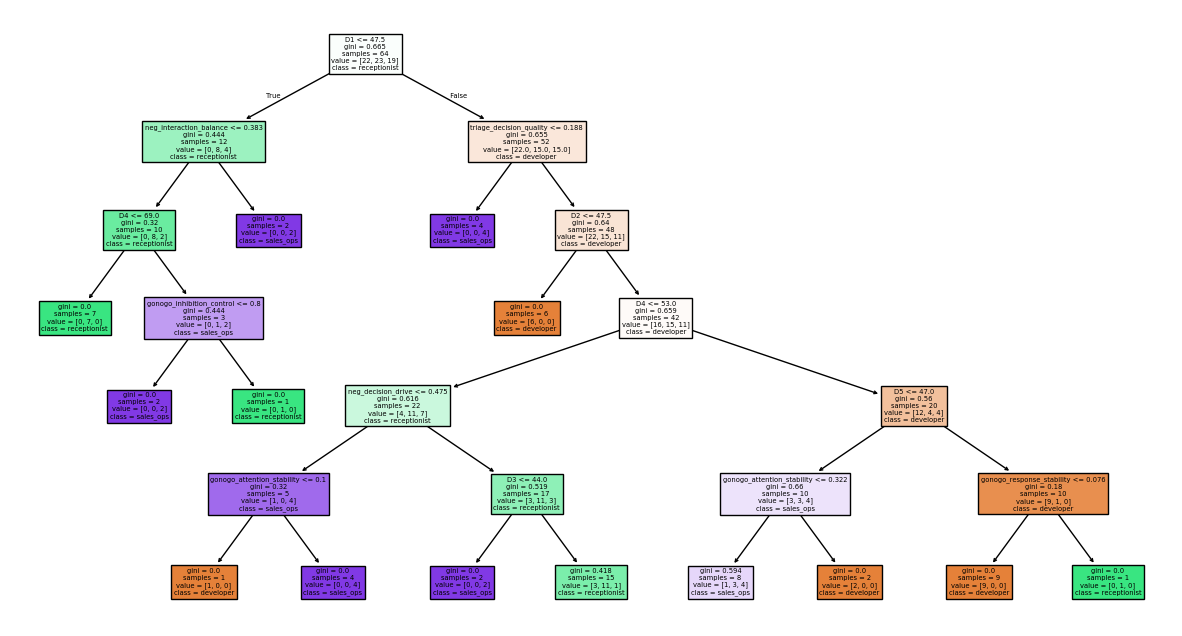

In [149]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(dt_B, feature_names=X_B.columns, class_names=dt_B.classes_, filled=True)
plt.show()

In [109]:
from sklearn.ensemble import GradientBoostingClassifier

In [150]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_B, y_train)
y_pred_gb = gb.predict(X_test_B)

print("=== GRADIENT BOOSTING ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

=== GRADIENT BOOSTING ===
Accuracy: 0.4642857142857143
              precision    recall  f1-score   support

   developer       0.57      0.40      0.47        10
receptionist       0.42      0.50      0.45        10
   sales_ops       0.44      0.50      0.47         8

    accuracy                           0.46        28
   macro avg       0.48      0.47      0.47        28
weighted avg       0.48      0.46      0.46        28



In [112]:
selected_features = [
    "gonogo_response_stability",    
    "D2",                           
    "neg_outcome_quality",           
    "D1",                            
    "triage_decision_speed",        
    "gonogo_attention_stability",   
    "D5",                           
    "neg_decision_drive"            
]

In [113]:
X_sel = df[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.3, random_state=42, stratify=y
)

rf_sel = RandomForestClassifier(random_state=42)
rf_sel.fit(X_train, y_train)

y_pred_sel = rf_sel.predict(X_test)

print("=== MODEL SELECTED FEATURES ===")
print("Accuracy:", accuracy_score(y_test, y_pred_sel))
print(classification_report(y_test, y_pred_sel))

=== MODEL SELECTED FEATURES ===
Accuracy: 0.4642857142857143
              precision    recall  f1-score   support

   developer       0.50      0.60      0.55        10
receptionist       0.33      0.30      0.32        10
   sales_ops       0.57      0.50      0.53         8

    accuracy                           0.46        28
   macro avg       0.47      0.47      0.46        28
weighted avg       0.46      0.46      0.46        28



In [248]:
import pandas as pd

# copia dataset
df_model = df.copy()

# =========================
# 1. GO / NO-GO → AGGREGAZIONE
# =========================

# controllo che le colonne esistano
gonogo_cols = [
    "gonogo_inhibition_control",
    "gonogo_attention_stability"
]

if all(col in df_model.columns for col in gonogo_cols):
    df_model["gonogo_control"] = df_model[gonogo_cols].mean(axis=1)

    # rimuovi originali
    df_model = df_model.drop(columns=gonogo_cols)

# =========================
# 2. NEGOTIATION → SELEZIONE
# =========================

neg_cols = [
    "neg_interaction_balance",
    "neg_decision_drive",
    "neg_outcome_quality"
]

# tieni solo la migliore
if "neg_outcome_quality" in df_model.columns:
    df_model = df_model.drop(
        columns=[c for c in neg_cols if c != "neg_outcome_quality"],
        errors="ignore"
    )

# =========================
# 3. DEFINIZIONE FEATURE
# =========================

orientation_cols = [
    "D1", "D2", "D3", "D4", "D5",
    "D6_result", "D6_learning", "D6_relation"
]

game_cols = [
    "triage_decision_quality",
    "triage_strategy_adaptation",
    "triage_decision_speed",
    "gonogo_control",
    "gonogo_response_stability",
    "neg_outcome_quality"
]

# =========================
# 4. DATASET FINALE
# =========================

X = df_model[orientation_cols + game_cols]
y = df_model["target_role"]

print("Shape X:", X.shape)
print("\nColonne finali:")
print(X.columns)

print("\nDistribuzione target:")
print(y.value_counts())

# =========================
# 5. CHECK CORRELATION (opzionale)
# =========================

print("\nCorrelazione media assoluta:")
print(X.corr().abs().mean().mean())

Shape X: (92, 14)

Colonne finali:
Index(['D1', 'D2', 'D3', 'D4', 'D5', 'D6_result', 'D6_learning', 'D6_relation',
       'triage_decision_quality', 'triage_strategy_adaptation',
       'triage_decision_speed', 'gonogo_control', 'gonogo_response_stability',
       'neg_outcome_quality'],
      dtype='str')

Distribuzione target:
target_role
receptionist    33
developer       32
sales_ops       27
Name: count, dtype: int64

Correlazione media assoluta:
0.2056265553560452


In [249]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (64, 14)
Test: (28, 14)


In [250]:
print(X.shape)
print(y.shape)

(92, 14)
(92,)


In [251]:
X_A = df_model[orientation_cols]
X_B = X

Train shape: (64, 14)
Test shape: (28, 14)

=== RANDOM FOREST (DATASET RIDOTTO) ===
Accuracy: 0.35714285714285715

Classification Report:
              precision    recall  f1-score   support

   developer       0.50      0.60      0.55        10
receptionist       0.25      0.20      0.22        10
   sales_ops       0.25      0.25      0.25         8

    accuracy                           0.36        28
   macro avg       0.33      0.35      0.34        28
weighted avg       0.34      0.36      0.35        28



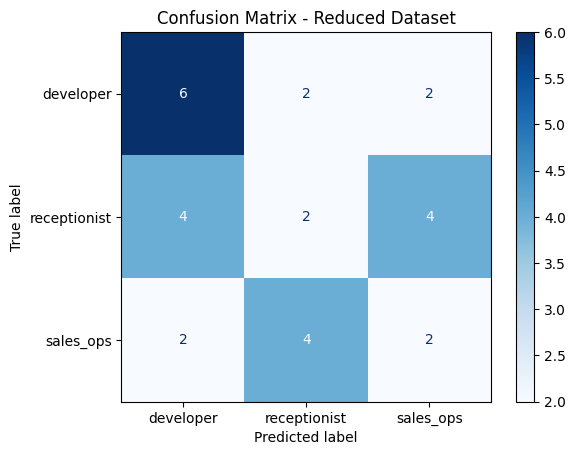


=== FEATURE IMPORTANCE ===
gonogo_response_stability     0.126634
neg_outcome_quality           0.085745
triage_decision_speed         0.084318
D2                            0.082379
D1                            0.078599
D5                            0.072779
D4                            0.070758
gonogo_control                0.065106
triage_decision_quality       0.062560
D3                            0.060362
D6_result                     0.056150
D6_learning                   0.055539
triage_strategy_adaptation    0.055242
D6_relation                   0.043830
dtype: float64


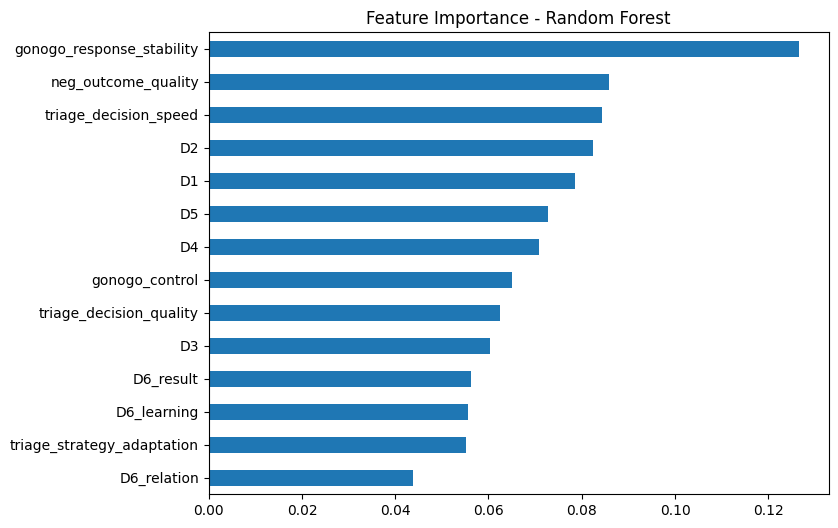

In [252]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================
# 1. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 2. MODELLO
# =========================

rf = RandomForestClassifier(
    max_depth=200,
    random_state=42
)

rf.fit(X_train, y_train)

# =========================
# 3. PREDIZIONI
# =========================

y_pred = rf.predict(X_test)

# =========================
# 4. METRICHE
# =========================

print("\n=== RANDOM FOREST (DATASET RIDOTTO) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 5. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Reduced Dataset")
plt.show()

# =========================
# 6. FEATURE IMPORTANCE
# =========================

importances = rf.feature_importances_

feat_imp = (
    pd.Series(importances, index=X_train.columns)
    .sort_values(ascending=False)
)

print("\n=== FEATURE IMPORTANCE ===")
print(feat_imp)

# grafico
plt.figure(figsize=(8, 6))
feat_imp.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

In [161]:
from scipy.stats import f_oneway

results = []

for col in X.columns:
    groups = [X[y == cls][col] for cls in y.unique()]
    f_stat, p_val = f_oneway(*groups)
    
    results.append({
        "feature": col,
        "p_value": p_val
    })

df_anova = pd.DataFrame(results).sort_values("p_value")

df_anova.head(10)

,feature,p_value
1,D2,0.012390
0,D1,0.021637
13,neg_outcome_quality,0.036466
7,D6_relation,0.046392
6,D6_learning,0.124509
8,triage_decision_quality,0.220083
4,D5,0.250232
12,gonogo_response_stability,0.389928
10,triage_decision_speed,0.459442
3,D4,0.592667


In [162]:
from scipy.stats import pearsonr
import pandas as pd

# prendi tutte le variabili numeriche ORIGINALI
df_num_full = df.select_dtypes(include="number").copy()

# rimuovi solo roba tecnica (non feature)
cols_to_exclude = [
    "distance_to_center",
    "PC1",
    "PC2",
    "cluster"
]

df_num_full = df_num_full.drop(columns=cols_to_exclude, errors="ignore")

results = []

cols = df_num_full.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r, p = pearsonr(df_num_full[cols[i]], df_num_full[cols[j]])
        
        results.append({
            "var1": cols[i],
            "var2": cols[j],
            "corr": r,
            "p_value": p
        })

df_corr_full = pd.DataFrame(results)

# solo relazioni significative
df_corr_sig = df_corr_full[df_corr_full["p_value"] < 0.05]

df_corr_sig.sort_values("p_value").head(20)

,var1,var2,corr,p_value
151,neg_interaction_balance,neg_outcome_quality,-0.932884,1.095512e-41
150,neg_interaction_balance,neg_decision_drive,-0.839324,1.496869e-25
138,gonogo_inhibition_control,gonogo_attention_stability,-0.834649,4.878471e-25
152,neg_decision_drive,neg_outcome_quality,0.781954,3.568795e-20
87,D6_result,D6_learning,0.698241,1.021979e-14
38,D2,D6_relation,0.456126,4.891837e-06
132,triage_decision_speed,gonogo_inhibition_control,-0.414657,3.965731e-05
133,triage_decision_speed,gonogo_attention_stability,0.400595,7.593582e-05
98,D6_learning,D6_relation,0.389939,1.218949e-04
106,D6_learning,neg_decision_drive,0.380989,1.791782e-04


Shape X: (92, 17)

Distribuzione y:
target_role
receptionist    33
developer       32
sales_ops       27
Name: count, dtype: int64

Train shape: (64, 17)
Test shape: (28, 17)

=== NEURAL NETWORK (MLP) ===
Accuracy: 0.25

Classification Report:
              precision    recall  f1-score   support

   developer       0.36      0.40      0.38        10
receptionist       0.14      0.10      0.12        10
   sales_ops       0.20      0.25      0.22         8

    accuracy                           0.25        28
   macro avg       0.24      0.25      0.24        28
weighted avg       0.24      0.25      0.24        28



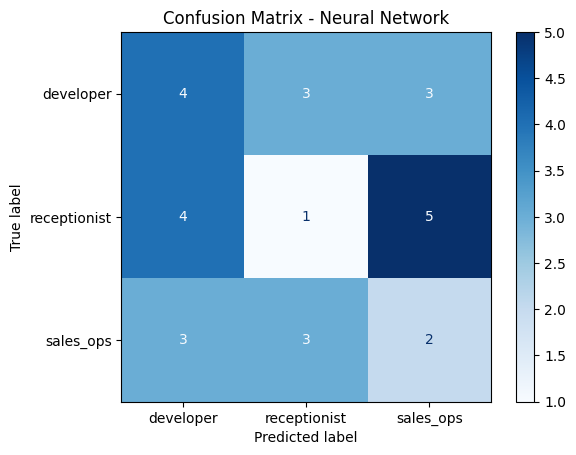

In [261]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



# =========================
# 2. COSTRUZIONE X E y
# =========================

X_B = df[features]
y

print("Shape X:", X_B.shape)
print("\nDistribuzione y:")
print(y.value_counts())

# =========================
# 3. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_B,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 4. STANDARDIZZAZIONE
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 5. MODELLO MLP
# =========================

mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

# =========================
# 6. PREDIZIONE
# =========================

y_pred = mlp.predict(X_test_scaled)

# =========================
# 7. METRICHE
# =========================

print("\n=== NEURAL NETWORK (MLP) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 8. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp.classes_)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Neural Network")
plt.show()

c:\Users\feder\Documents\tesi-ml\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\feder\Documents\tesi-ml\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\feder\Documents\tesi-ml\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\feder\Documents\tesi-ml\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\feder\D

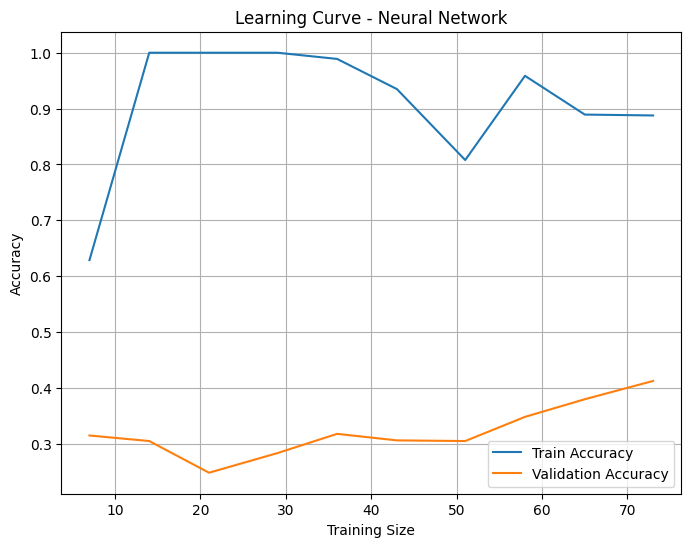

In [217]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# =========================
# MODELLO (stesso MLP)
# =========================

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

# =========================
# LEARNING CURVE
# =========================

train_sizes, train_scores, val_scores = learning_curve(
    mlp,
    X_full,  # usa FULL dataset
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# media
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# =========================
# PLOT
# =========================

plt.figure(figsize=(8, 6))

plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Neural Network")
plt.legend()

plt.grid()
plt.show()

In [168]:
# accuracy usando solo giochi
X_games = df[game_cols_full]
y = df["target_role"]

X_train_D, X_test_D, y_train, y_test = train_test_split(
    X_games, y, test_size=0.3, random_state=42, stratify=y
)

# modello veloce

In [171]:
rf_D = RandomForestClassifier(random_state=42)
rf_D.fit(X_train_D, y_train)

y_pred_D = rf_D.predict(X_test_D)

print("=== MODEL A (MINIGIOCHI) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_D))
print(classification_report(y_test, y_pred_D))

=== MODEL A (MINIGIOCHI) ===
Accuracy: 0.32142857142857145
              precision    recall  f1-score   support

   developer       0.38      0.30      0.33        10
receptionist       0.33      0.30      0.32        10
   sales_ops       0.27      0.38      0.32         8

    accuracy                           0.32        28
   macro avg       0.33      0.33      0.32        28
weighted avg       0.33      0.32      0.32        28



In [174]:
from sklearn.linear_model import LinearRegression

X = df[["D3"]]
y = df["triage_decision_quality"]

model =LinearRegression().fit(X, y)

# coefficiente
print("Coefficiente:", model.coef_[0])

# intercetta
print("Intercept:", model.intercept_)

# R²
print("R^2:", model.score(X, y))

Coefficiente: -0.00042251096048874726
Intercept: 0.5489614700093836
R^2: 0.001789536276726733


<Axes: xlabel='job_satisfaction'>

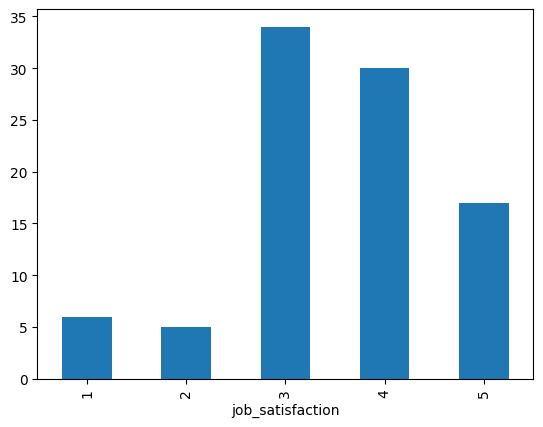

In [175]:
df["job_satisfaction"].value_counts().sort_index().plot(kind="bar")

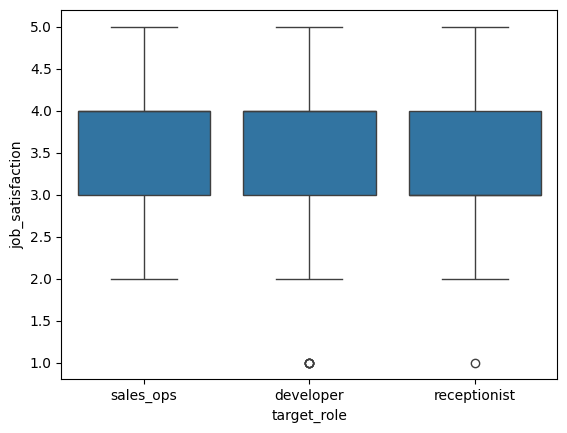

In [176]:
import seaborn as sns

sns.boxplot(x="target_role", y="job_satisfaction", data=df)
plt.show()

In [177]:
df["match"] = df["target_role"] == df["suggested_role"]

<Axes: xlabel='match', ylabel='job_satisfaction'>

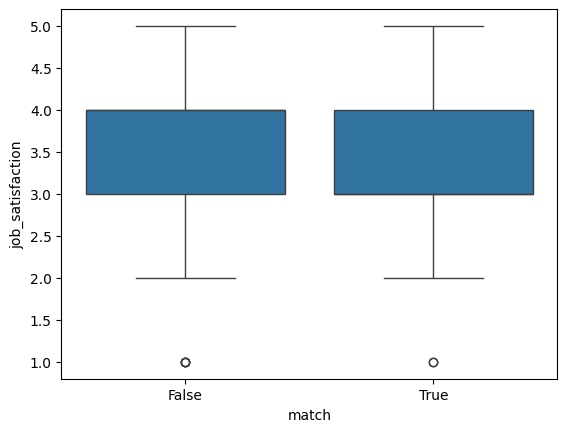

In [178]:
sns.boxplot(x="match", y="job_satisfaction", data=df)

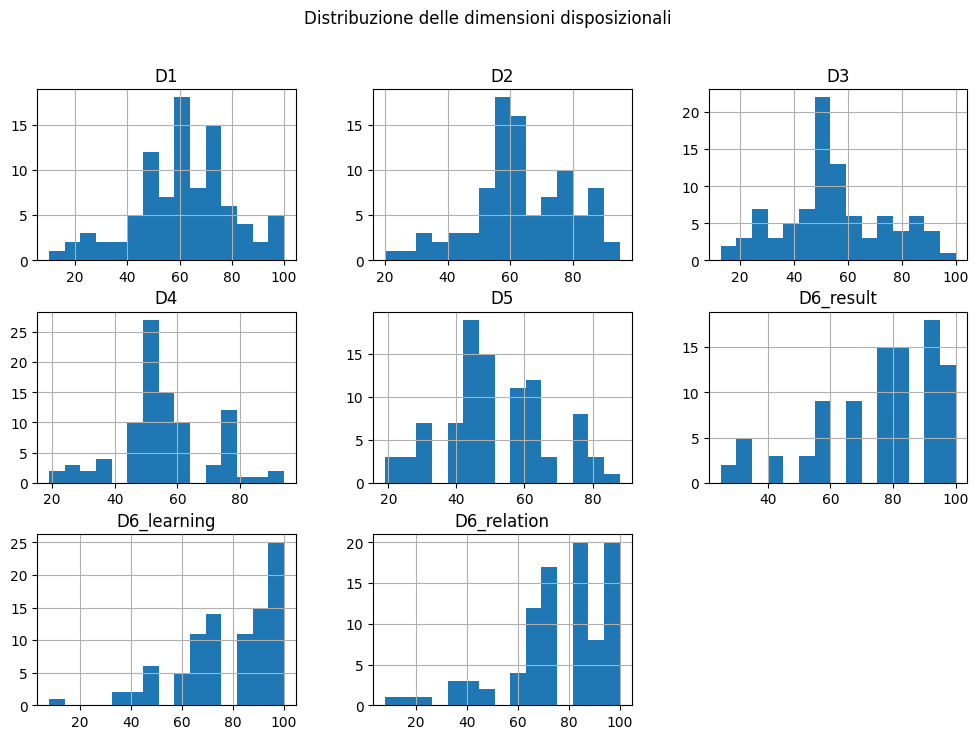

In [179]:
import matplotlib.pyplot as plt

cols = ["D1","D2","D3","D4","D5","D6_result","D6_learning","D6_relation"]

df[cols].hist(bins=15, figsize=(12,8))
plt.suptitle("Distribuzione delle dimensioni disposizionali")
plt.show()

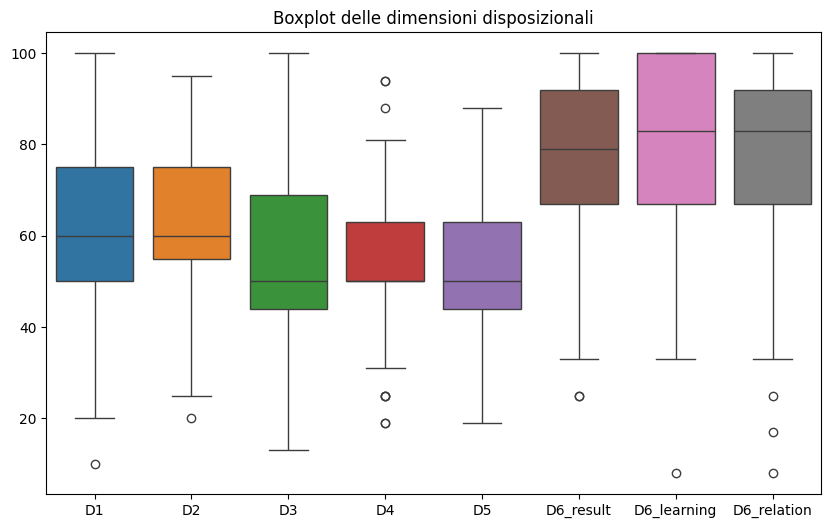

In [180]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df[cols])
plt.title("Boxplot delle dimensioni disposizionali")
plt.show()

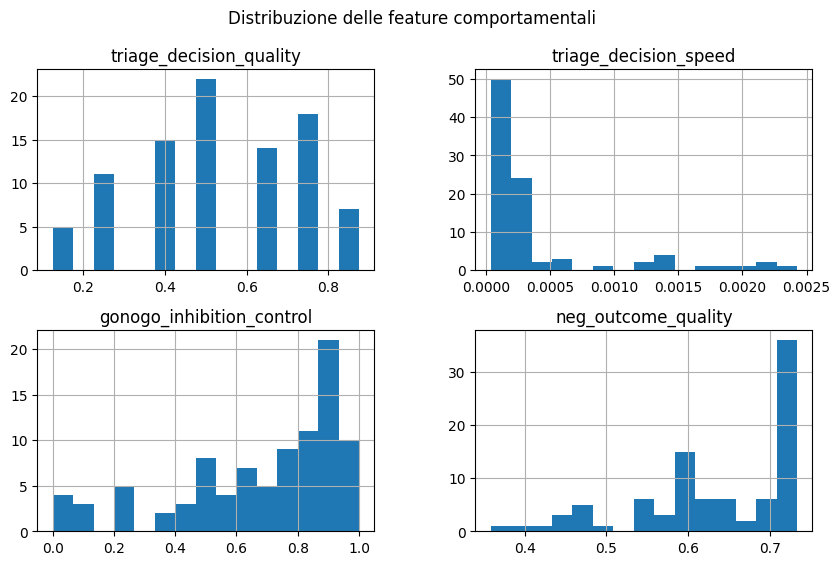

In [181]:
game_cols = [
    "triage_decision_quality",
    "triage_decision_speed",
    "gonogo_inhibition_control",
    "neg_outcome_quality"
]

df[game_cols].hist(bins=15, figsize=(10,6))
plt.suptitle("Distribuzione delle feature comportamentali")
plt.show()

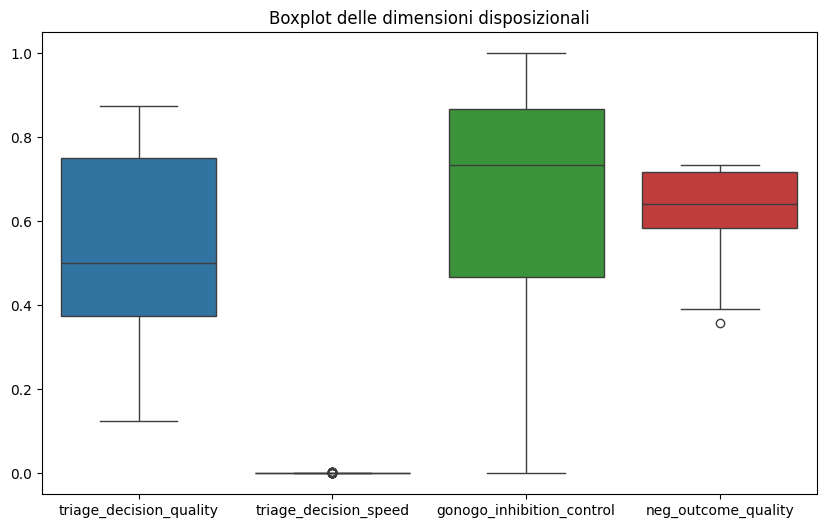

In [183]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df[game_cols])
plt.title("Boxplot delle dimensioni disposizionali")
plt.show()

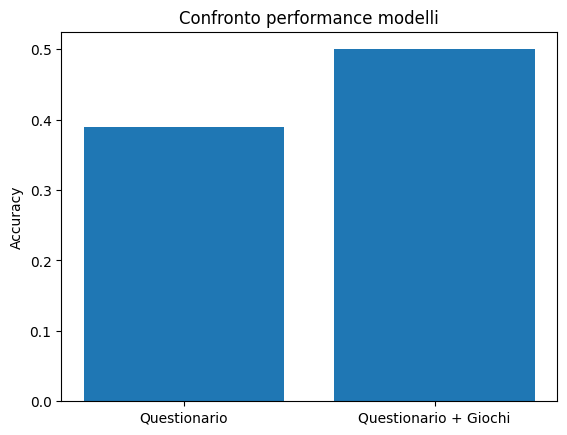

In [184]:
models = ["Questionario", "Questionario + Giochi"]
accuracy = [0.39, 0.50]

plt.bar(models, accuracy)
plt.title("Confronto performance modelli")
plt.ylabel("Accuracy")
plt.show()

In [186]:
orientation_cols = [
    "D1", "D2", "D3", "D4", "D5",
    "D6_result", "D6_learning", "D6_relation"
]

game_cols_full = [
    "triage_decision_quality",
    "triage_strategy_adaptation",
    "triage_decision_speed",
    "gonogo_inhibition_control",
    "gonogo_attention_stability",
    "gonogo_response_stability",
    "neg_interaction_balance",
    "neg_decision_drive",
    "neg_outcome_quality"
]

X_B = df[orientation_cols + game_cols_full].copy()
y = df["target_role"].copy()

print(y.dtype)
print(y.value_counts())

str
target_role
receptionist    33
developer       32
sales_ops       27
Name: count, dtype: int64


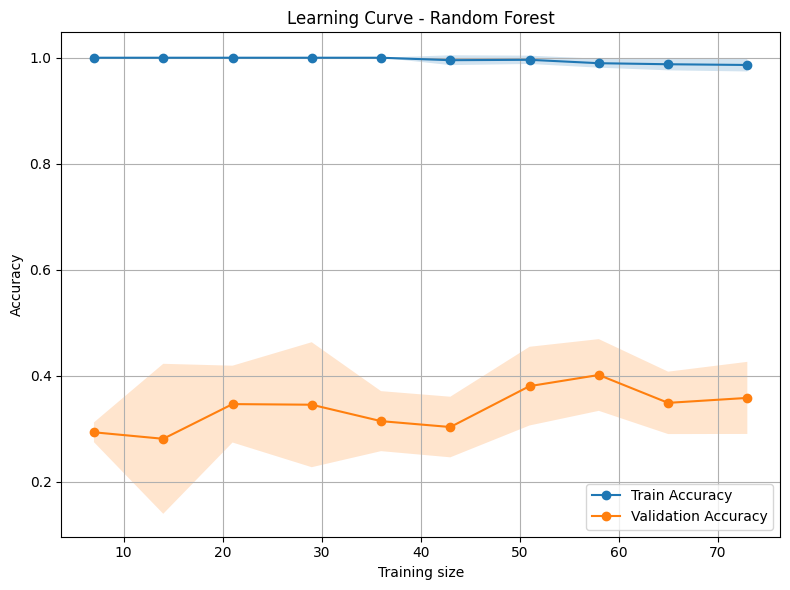

Train sizes: [ 7 14 21 29 36 43 51 58 65 73]
Train mean: [1.         1.         1.         1.         1.         0.99534884
 0.99607843 0.98965517 0.98769231 0.98630137]
Validation mean: [0.29298246 0.28070175 0.34619883 0.34502924 0.31403509 0.30292398
 0.38011696 0.40116959 0.34853801 0.35789474]


In [189]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. MODELLO
# =========================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# =========================
# 2. LEARNING CURVE
# =========================

train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf,
    X=X_B,
    y=y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# medie e deviazioni standard
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# =========================
# 3. PLOT
# =========================

plt.figure(figsize=(8, 6))

plt.plot(train_sizes, train_mean, marker="o", label="Train Accuracy")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Accuracy")

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 4. STAMPA VALORI
# =========================

print("Train sizes:", train_sizes)
print("Train mean:", train_mean)
print("Validation mean:", val_mean)

In [188]:
print("Train mean:", train_mean)
print("Validation mean:", val_mean)

Train mean: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Validation mean: [0.29298246 0.29181287 0.33450292 0.34619883 0.30409357 0.30409357
 0.3374269  0.40292398 0.3374269  0.33625731]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [191]:
orientation_cols = [
    "D1", "D2", "D3", "D4", "D5",
    "D6_result", "D6_learning", "D6_relation"
]

game_cols = [
    "triage_decision_quality",
    "triage_strategy_adaptation",
    "triage_decision_speed",
    "gonogo_inhibition_control",
    "gonogo_attention_stability",
    "gonogo_response_stability",
    "neg_interaction_balance",
    "neg_decision_drive",
    "neg_outcome_quality"
]

X_A = df[orientation_cols].copy()
X_B = df[orientation_cols + game_cols].copy()
X_C = df[game_cols].copy()

y = df["target_role"].copy()

print("Shape X_A:", X_A.shape)
print("Shape X_B:", X_B.shape)
print("Shape X_C:", X_C.shape)
print("\nDistribuzione target:")
print(y.value_counts())

Shape X_A: (92, 8)
Shape X_B: (92, 17)
Shape X_C: (92, 9)

Distribuzione target:
target_role
receptionist    33
developer       32
sales_ops       27
Name: count, dtype: int64


In [192]:
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_A_train, X_A_test = X_A.loc[idx_train], X_A.loc[idx_test]
X_B_train, X_B_test = X_B.loc[idx_train], X_B.loc[idx_test]
X_C_train, X_C_test = X_C.loc[idx_train], X_C.loc[idx_test]

y_train, y_test = y.loc[idx_train], y.loc[idx_test]

print("Train size:", len(idx_train))
print("Test size:", len(idx_test))
print("\nDistribuzione y_train:")
print(y_train.value_counts())
print("\nDistribuzione y_test:")
print(y_test.value_counts())

Train size: 64
Test size: 28

Distribuzione y_train:
target_role
receptionist    23
developer       22
sales_ops       19
Name: count, dtype: int64

Distribuzione y_test:
target_role
receptionist    10
developer       10
sales_ops        8
Name: count, dtype: int64


In [193]:
models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            max_iter=2000,
            random_state=42
        ))
    ])
}

In [206]:
configs = {
    "A - Solo dichiarative": (X_A_train, X_A_test),
    "B - Dichiarative + comportamentali": (X_B_train, X_B_test),
    "C - Solo comportamentali": (X_C_train, X_C_test)
}

In [207]:
def evaluate_model(model_name, model, config_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=sorted(y.unique()), zero_division=0
    )

    class_report = classification_report(y_test, y_pred, zero_division=0)

    print(f"\n=== {model_name} | {config_name} ===")
    print("Accuracy:", acc)
    print(class_report)

    return {
        "model_name": model_name,
        "config_name": config_name,
        "model_obj": model,
        "y_pred": y_pred,
        "accuracy": acc,
        "precision_macro": precision_recall_fscore_support(
            y_test, y_pred, average="macro", zero_division=0
        )[0],
        "recall_macro": precision_recall_fscore_support(
            y_test, y_pred, average="macro", zero_division=0
        )[1],
        "f1_macro": precision_recall_fscore_support(
            y_test, y_pred, average="macro", zero_division=0
        )[2]
    }

In [208]:
results = []

for model_name, model in models.items():
    for config_name, (X_train_cfg, X_test_cfg) in configs.items():
        res = evaluate_model(
            model_name=model_name,
            model=model,
            config_name=config_name,
            X_train=X_train_cfg,
            X_test=X_test_cfg,
            y_train=y_train,
            y_test=y_test
        )
        results.append(res)


=== SVM | A - Solo dichiarative ===
Accuracy: 0.42857142857142855
              precision    recall  f1-score   support

   developer       0.58      0.70      0.64        10
receptionist       0.27      0.30      0.29        10
   sales_ops       0.40      0.25      0.31         8

    accuracy                           0.43        28
   macro avg       0.42      0.42      0.41        28
weighted avg       0.42      0.43      0.42        28


=== SVM | B - Dichiarative + comportamentali ===
Accuracy: 0.42857142857142855
              precision    recall  f1-score   support

   developer       0.47      0.70      0.56        10
receptionist       0.40      0.40      0.40        10
   sales_ops       0.33      0.12      0.18         8

    accuracy                           0.43        28
   macro avg       0.40      0.41      0.38        28
weighted avg       0.40      0.43      0.39        28


=== SVM | C - Solo comportamentali ===
Accuracy: 0.39285714285714285
              precisi

In [209]:
results_df = pd.DataFrame([
    {
        "Algoritmo": r["model_name"],
        "Configurazione": r["config_name"],
        "Accuracy": r["accuracy"],
        "Precision_macro": r["precision_macro"],
        "Recall_macro": r["recall_macro"],
        "F1_macro": r["f1_macro"]
    }
    for r in results
])

results_df = results_df.sort_values(["Algoritmo", "Configurazione"]).reset_index(drop=True)

print(results_df)

        Algoritmo                      Configurazione  Accuracy  \
0  Neural Network               A - Solo dichiarative  0.392857   
1  Neural Network  B - Dichiarative + comportamentali  0.250000   
2  Neural Network            C - Solo comportamentali  0.321429   
3   Random Forest               A - Solo dichiarative  0.357143   
4   Random Forest  B - Dichiarative + comportamentali  0.500000   
5   Random Forest            C - Solo comportamentali  0.321429   
6             SVM               A - Solo dichiarative  0.428571   
7             SVM  B - Dichiarative + comportamentali  0.428571   
8             SVM            C - Solo comportamentali  0.392857   

   Precision_macro  Recall_macro  F1_macro  
0         0.400433      0.391667  0.389577  
1         0.235498      0.250000  0.240274  
2         0.322222      0.316667  0.316450  
3         0.351852      0.350000  0.350361  
4         0.496633      0.500000  0.497494  
5         0.327020      0.325000  0.321637  
6         0.41

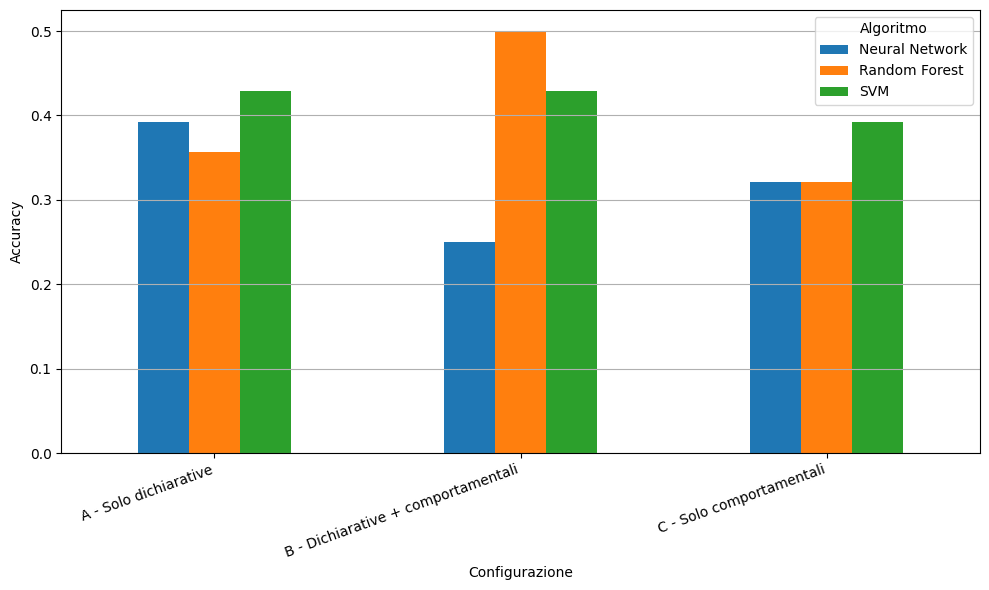

In [210]:
pivot_acc = results_df.pivot(index="Configurazione", columns="Algoritmo", values="Accuracy")

pivot_acc.plot(kind="bar", figsize=(10, 6))

plt.ylabel("Accuracy")
plt.xlabel("Configurazione")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

<Figure size 500x400 with 0 Axes>

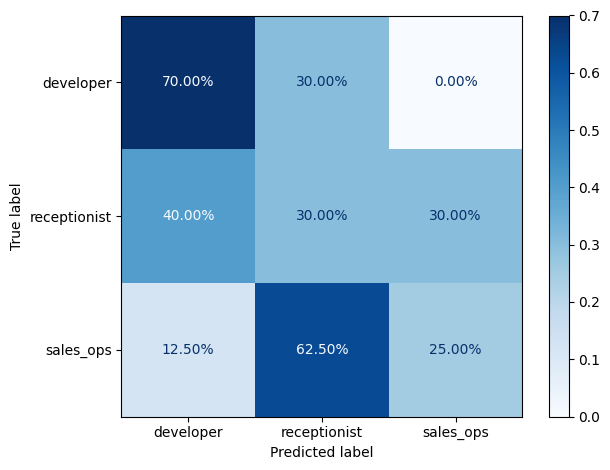

<Figure size 500x400 with 0 Axes>

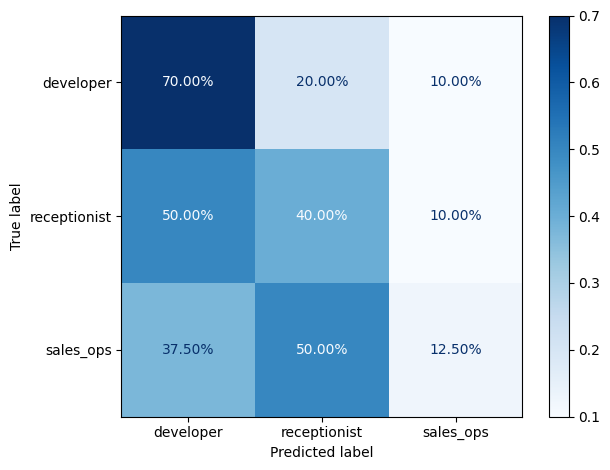

<Figure size 500x400 with 0 Axes>

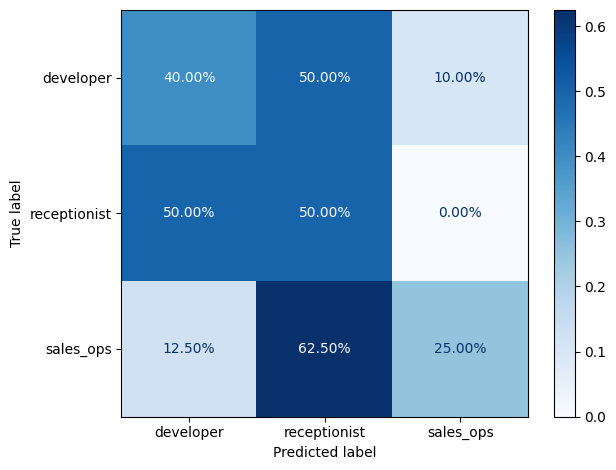

<Figure size 500x400 with 0 Axes>

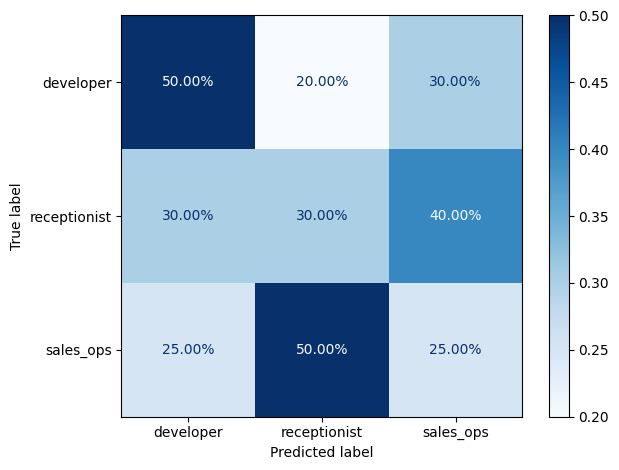

<Figure size 500x400 with 0 Axes>

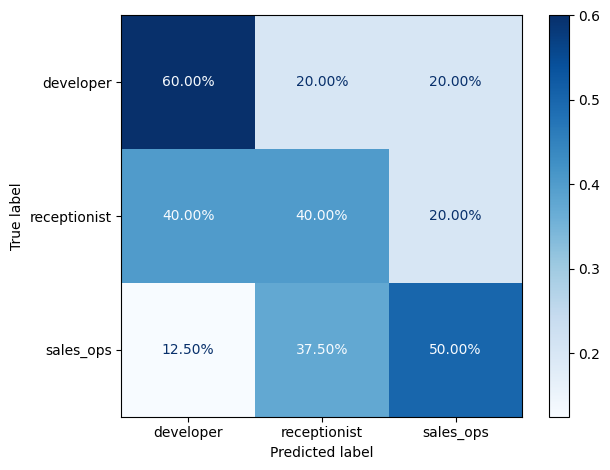

<Figure size 500x400 with 0 Axes>

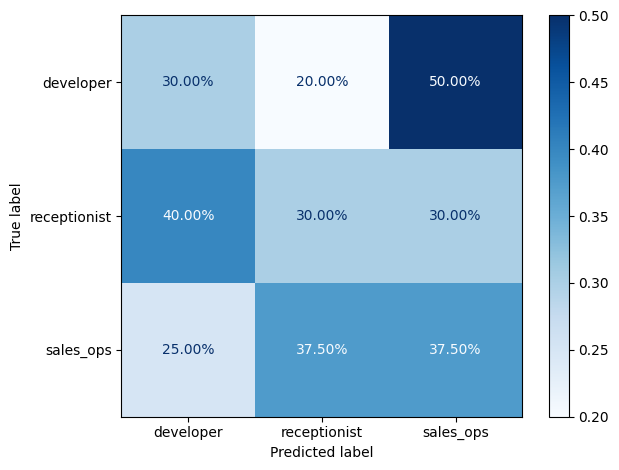

<Figure size 500x400 with 0 Axes>

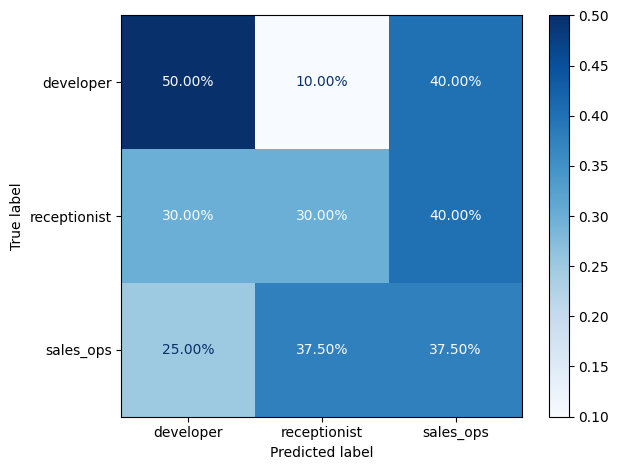

<Figure size 500x400 with 0 Axes>

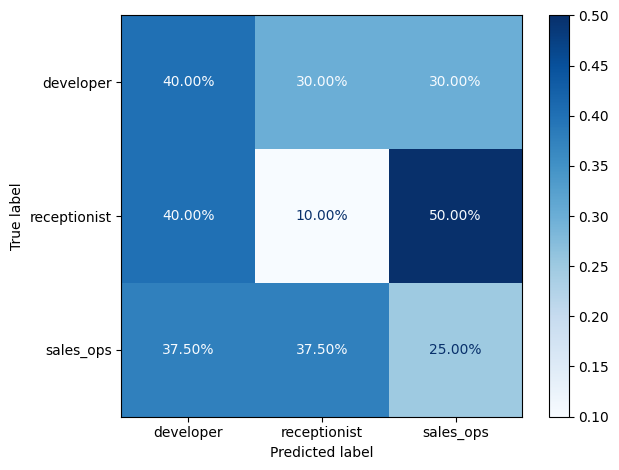

<Figure size 500x400 with 0 Axes>

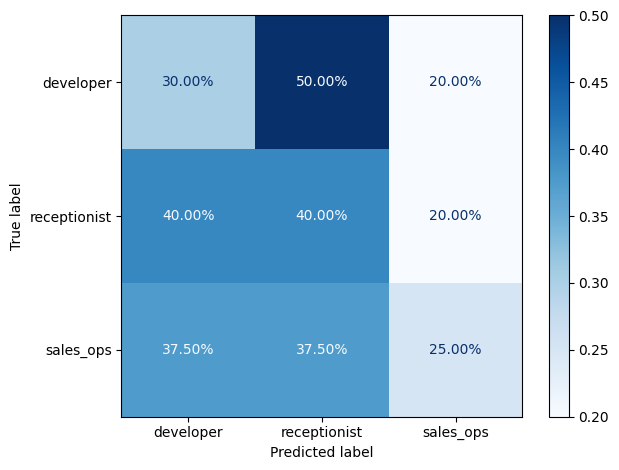

In [212]:
for r in results:
    plt.figure(figsize=(5, 4))
    
    cm = confusion_matrix(y_test, r["y_pred"], labels=sorted(y.unique()))
    
    # normalizzazione per riga (percentuali)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=sorted(y.unique())
    )
    
    disp.plot(cmap="Blues", values_format=".2%")
    
    #plt.title(f"{r['model_name']} | {r['config_name']} (%)")
    plt.tight_layout()
    plt.show()

In [201]:
df["match_baseline"] = df["suggested_role"] == df["target_role"]

baseline_accuracy = df["match_baseline"].mean()

print("Baseline accuracy (suggested_role vs target_role):", baseline_accuracy)

print("\nDistribuzione match:")
print(df["match_baseline"].value_counts())

Baseline accuracy (suggested_role vs target_role): 0.44565217391304346

Distribuzione match:
match_baseline
False    51
True     41
Name: count, dtype: int64


In [202]:
baseline_row = pd.DataFrame([{
    "Algoritmo": "Baseline sistema",
    "Configurazione": "suggested_role vs target_role",
    "Accuracy": baseline_accuracy,
    "Precision_macro": np.nan,
    "Recall_macro": np.nan,
    "F1_macro": np.nan
}])

results_with_baseline = pd.concat([baseline_row, results_df], ignore_index=True)

print(results_with_baseline)

          Algoritmo                 Configurazione  Accuracy  Precision_macro  \
0  Baseline sistema  suggested_role vs target_role  0.445652              NaN   
1    Neural Network          A - Solo dichiarative  0.392857         0.400433   
2    Neural Network  B - Dichiarative + minigiochi  0.250000         0.235498   
3    Neural Network            C - Solo minigiochi  0.321429         0.322222   
4     Random Forest          A - Solo dichiarative  0.357143         0.351852   
5     Random Forest  B - Dichiarative + minigiochi  0.500000         0.496633   
6     Random Forest            C - Solo minigiochi  0.321429         0.327020   
7               SVM          A - Solo dichiarative  0.428571         0.418687   
8               SVM  B - Dichiarative + minigiochi  0.428571         0.400000   
9               SVM            C - Solo minigiochi  0.392857         0.466667   

   Recall_macro  F1_macro  
0           NaN       NaN  
1      0.391667  0.389577  
2      0.250000  0.24027

In [203]:
detailed_rows = []

for r in results:
    report = classification_report(y_test, r["y_pred"], output_dict=True, zero_division=0)

    for cls in sorted(y.unique()):
        detailed_rows.append({
            "Algoritmo": r["model_name"],
            "Configurazione": r["config_name"],
            "Classe": cls,
            "Precision": report[cls]["precision"],
            "Recall": report[cls]["recall"],
            "F1-score": report[cls]["f1-score"],
            "Support": report[cls]["support"]
        })

detailed_df = pd.DataFrame(detailed_rows)
print(detailed_df)

         Algoritmo                 Configurazione        Classe  Precision  \
0              SVM          A - Solo dichiarative     developer   0.583333   
1              SVM          A - Solo dichiarative  receptionist   0.272727   
2              SVM          A - Solo dichiarative     sales_ops   0.400000   
3              SVM  B - Dichiarative + minigiochi     developer   0.466667   
4              SVM  B - Dichiarative + minigiochi  receptionist   0.400000   
5              SVM  B - Dichiarative + minigiochi     sales_ops   0.333333   
6              SVM            C - Solo minigiochi     developer   0.400000   
7              SVM            C - Solo minigiochi  receptionist   0.333333   
8              SVM            C - Solo minigiochi     sales_ops   0.666667   
9    Random Forest          A - Solo dichiarative     developer   0.500000   
10   Random Forest          A - Solo dichiarative  receptionist   0.333333   
11   Random Forest          A - Solo dichiarative     sales_ops 

gonogo_response_stability     0.098751
D2                            0.082056
triage_decision_speed         0.064304
D4                            0.063525
D1                            0.062391
gonogo_attention_stability    0.062020
triage_decision_quality       0.059107
neg_outcome_quality           0.058219
neg_decision_drive            0.057027
triage_strategy_adaptation    0.056376
gonogo_inhibition_control     0.052712
D5                            0.052314
neg_interaction_balance       0.051934
D6_learning                   0.049060
D3                            0.047131
D6_result                     0.041915
D6_relation                   0.041157
dtype: float64


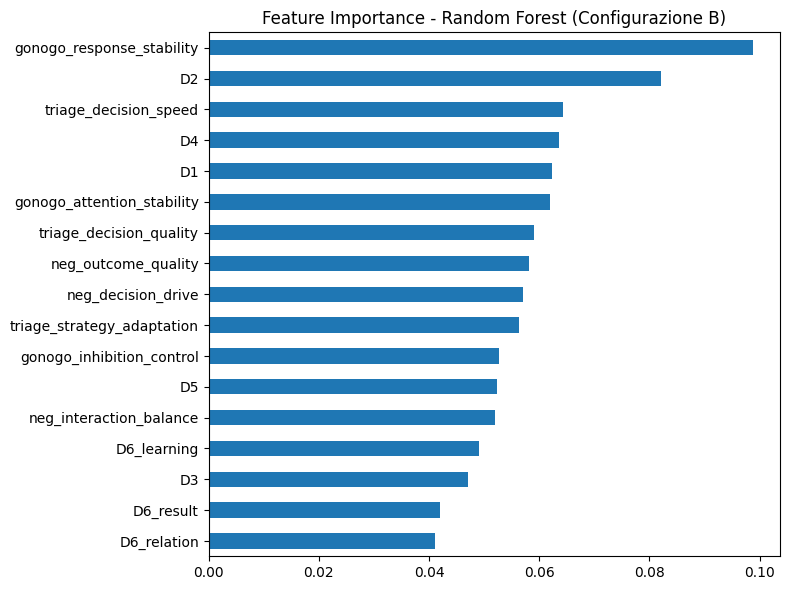

In [204]:
rf_B = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_B.fit(X_B_train, y_train)

feat_imp = pd.Series(
    rf_B.feature_importances_,
    index=X_B.columns
).sort_values(ascending=False)

print(feat_imp)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest (Configurazione B)")
plt.tight_layout()
plt.show()

In [214]:
cv_table = cv_results_df[["Algoritmo", "Configurazione", "CV Mean Accuracy", "CV Std"]].copy()

cv_table["CV Mean Accuracy"] = cv_table["CV Mean Accuracy"].round(3)
cv_table["CV Std"] = cv_table["CV Std"].round(3)

cv_table["Accuracy (mean ± std)"] = (
    cv_table["CV Mean Accuracy"].astype(str) + " ± " + cv_table["CV Std"].astype(str)
)

cv_table = cv_table[["Algoritmo", "Configurazione", "Accuracy (mean ± std)"]]

print(cv_table)

        Algoritmo                      Configurazione Accuracy (mean ± std)
0  Neural Network               A - Solo dichiarative          0.37 ± 0.067
1  Neural Network  B - Dichiarative + comportamentali         0.381 ± 0.054
2  Neural Network            C - Solo comportamentali         0.435 ± 0.114
3   Random Forest               A - Solo dichiarative         0.392 ± 0.056
4   Random Forest  B - Dichiarative + comportamentali         0.325 ± 0.053
5   Random Forest            C - Solo comportamentali         0.269 ± 0.159
6             SVM               A - Solo dichiarative         0.359 ± 0.058
7             SVM  B - Dichiarative + comportamentali           0.402 ± 0.1
8             SVM            C - Solo comportamentali         0.369 ± 0.049
